# Sexual Selection Experimental Evolution Analysis
Dataset: Experimental sexual selection affects the evolution of physiological and life-history traits

This notebook analyses:

- development time (eclosion)
- wing length (sexual dimorphism)
- desiccation resistance (survival)
- starvation resistance (survival)
- metabolic rate
- metabolite allocation

Biological questions:

1. Does sexual selection alter life history?
2. Does sexual conflict emerge?
3. Do males and females evolve differently?
4. Does sexual selection alter metabolism?
5. Does sexual selection change stress resistance?

Dataset:
https://datadryad.org/dataset/doi:10.5061/dryad.9cnp5hqhk

## 0. Environment setup
Create environment:

conda create -n sexual_selection python=3.11
conda activate sexual_selection

pip install pandas numpy matplotlib seaborn scipy statsmodels
pip install lifelines scikit-learn pingouin plotly

### Library check

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.decomposition import PCA
from lifelines import KaplanMeierFitter
import pingouin as pg

print("Libraries loaded")

Libraries loaded


## 1. Load data
Download dataset locally.

Provide folder path below.

In [29]:
DATA = "C:/Users/hi/Documents/YLL_evol/Multi-generation-evol-SS-env/"
eclosion = pd.read_csv(DATA+"1.eclosion_wide.csv")
wing = pd.read_csv(DATA+"1.wing_length.csv")
des = pd.read_csv(DATA+"2.DesRes.csv")
starv = pd.read_csv(DATA+"2.StarvRes.csv")
metabolic = pd.read_csv(DATA+"3.metabolic_rates.csv")
metabolite = pd.read_csv(DATA+"4.metabolite_data.csv")

### Raw data quality control
Check:

- missing values
- duplicates
- sample balance
- distributions

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Treatment   699 non-null    object 
 1   Rep         699 non-null    object 
 2   Sex         699 non-null    object 
 3   Seed        699 non-null    object 
 4   Slide       699 non-null    int64  
 5   Individual  699 non-null    int64  
 6   Side        699 non-null    object 
 7   Area        699 non-null    float64
 8   Mean        699 non-null    float64
 9   Min         699 non-null    float64
 10  Max         699 non-null    float64
 11  Length      699 non-null    float64
dtypes: float64(5), int64(2), object(5)
memory usage: 65.7+ KB


Text(0.5, 1.0, 'Wing length distribution')

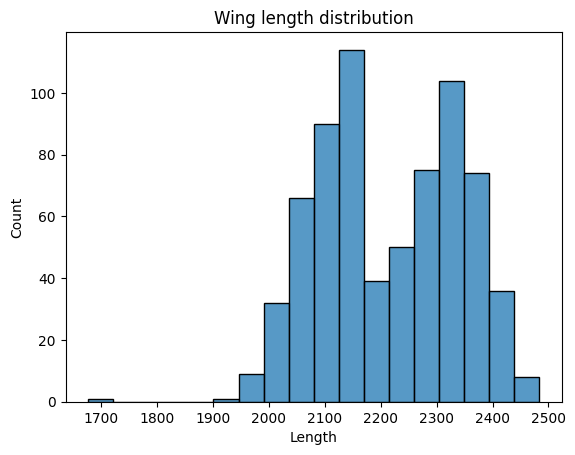

In [30]:
wing.info()
wing.isna().sum()
sns.histplot(wing["Length"])
plt.title("Wing length distribution")

### Descriptive statistics (beginning)
Understand baseline variation

In [7]:
wing.groupby(["Treatment","Sex"])["Length"].describe()

count         mean        std       min        25%       50%  \
Treatment Sex                                                                 
M         F    179.0  2319.590765  59.748323  2069.949  2277.4020  2316.721   
          M    180.0  2099.647583  59.440647  1677.605  2062.8655  2109.176   
P         F    165.0  2331.395921  61.738701  2150.910  2299.9610  2337.094   
          M    175.0  2119.490674  65.575457  1933.537  2080.0815  2134.394   

                     75%       max  
Treatment Sex                       
M         F    2359.3330  2483.238  
          M    2139.1655  2220.078  
P         F    2375.1120  2469.836  
          M    2160.9085  2258.806

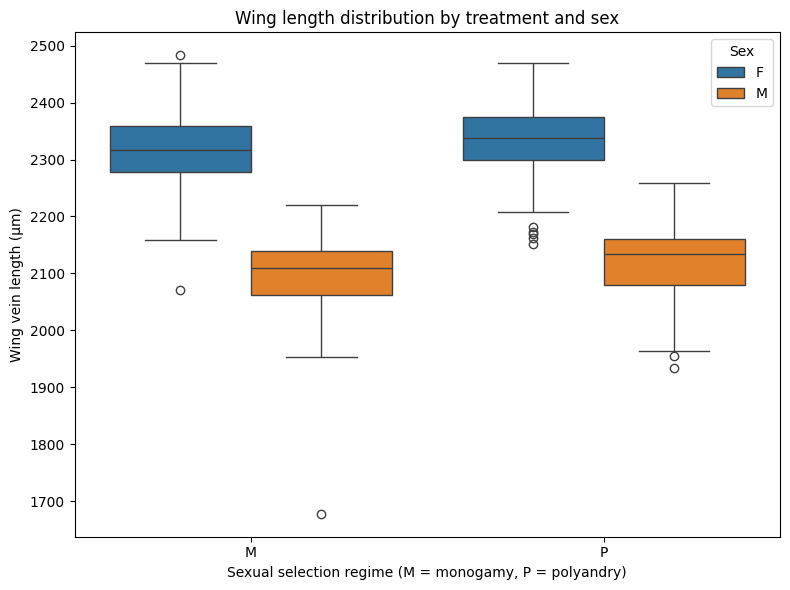

In [31]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=wing,
    x="Treatment",
    y="Length",
    hue="Sex"
)

plt.title("Wing length distribution by treatment and sex")
plt.xlabel("Sexual selection regime (M = monogamy, P = polyandry)")
plt.ylabel("Wing vein length (µm)")
plt.legend(title="Sex")

plt.tight_layout()

- P vs M shows sexual selection effect
- Male vs Female shows sexual dimorphism
- Interaction suggests sexual conflict

## 2. Development time analysis (Eclosion)
Method:
emergence curves

Reference:
Hollis et al 2014 — sexual selection experimental evolution

convert wide → long
to allow:
grouping by treatment
cumulative curves
survival-like analysis


plot emergence

Text(0, 0.5, 'Emergence count')

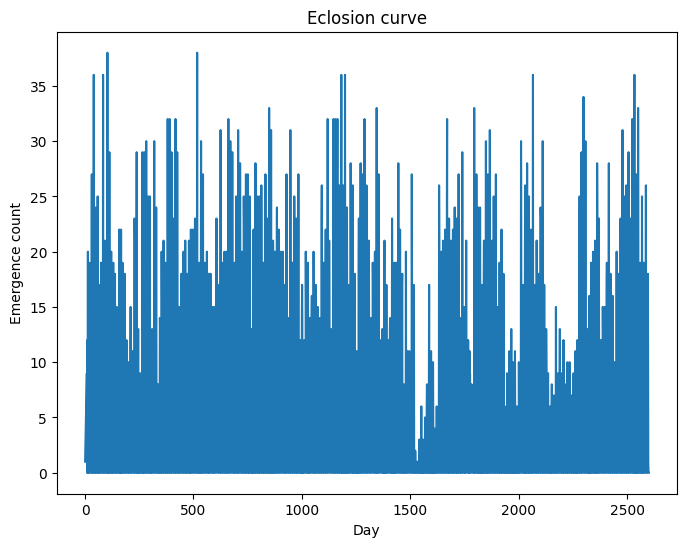

In [8]:
long = eclosion.melt(var_name="sample", value_name="count")

plt.figure(figsize=(8,6))
sns.lineplot(data=long, x=long.index, y="count")
plt.title("Eclosion curve")
plt.xlabel("Day")
plt.ylabel("Emergence count")



In [32]:
long = eclosion.reset_index().melt(
    id_vars="index",
    var_name="sample",
    value_name="count"
)

long = long.rename(columns={"index":"day"})

meta = long["sample"].str.split("_", expand=True)

long["treatment"] = meta[0].str[0]   # P or M
long["sex"] = meta[3]

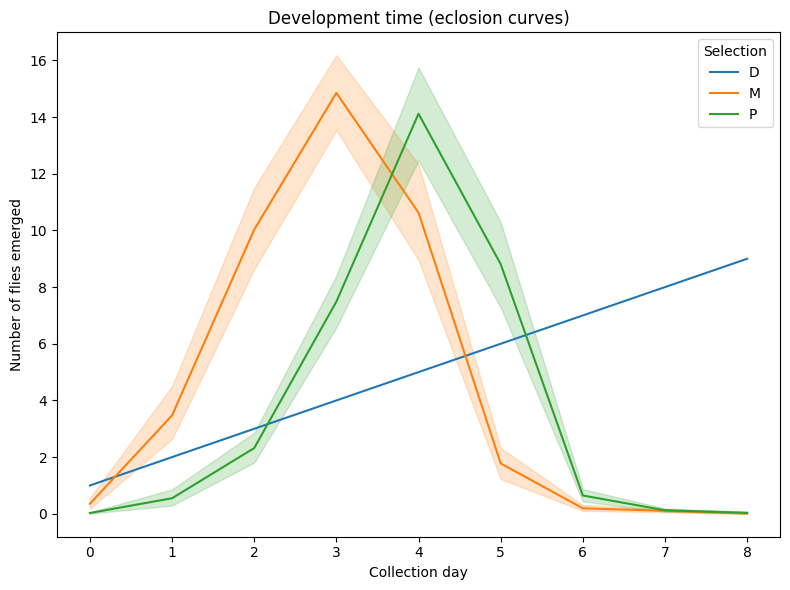

In [33]:
plt.figure(figsize=(8,6))

sns.lineplot(
    data=long,
    x="day",
    y="count",
    hue="treatment"
)

plt.title("Development time (eclosion curves)")
plt.xlabel("Collection day")
plt.ylabel("Number of flies emerged")
plt.legend(title="Selection")

plt.tight_layout()

Earlier emergence indicates faster development.
Differences between treatments indicate life history evolution.

## 3. Sexual dimorphism (Wing length)
Model:
Length ~ Treatment * Sex

Detect:
sexual selection
sexual dimorphism
sexual conflict

M = enforced monogamy
P = polyandry (strong sexual selection)

In [9]:
model = ols("Length ~ Treatment * Sex", data=wing).fit()
sm.stats.anova_lm(model)

,df,sum_sq,mean_sq,F,PR(>F)
Treatment,1.0,2.957542e+04,2.957542e+04,7.782374,5.420365e-03
Sex,1.0,8.152328e+06,8.152328e+06,2145.175230,1.241126e-214
Treatment:Sex,1.0,2.819230e+03,2.819230e+03,0.741842,3.893684e-01
Residual,695.0,2.641214e+06,3.800309e+03,NaN,NaN


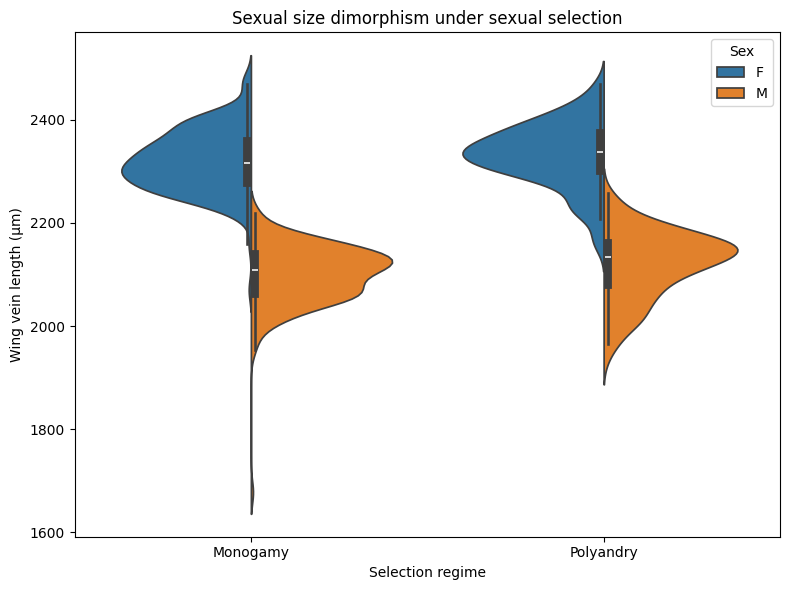

In [34]:
wing["Treatment"] = wing["Treatment"].map({
    "M":"Monogamy",
    "P":"Polyandry"
})

plt.figure(figsize=(8,6))

sns.violinplot(
    data=wing,
    x="Treatment",
    y="Length",
    hue="Sex",
    split=True
)

plt.title("Sexual size dimorphism under sexual selection")
plt.xlabel("Selection regime")
plt.ylabel("Wing vein length (µm)")

plt.legend(title="Sex")

plt.tight_layout()

Text(0, 0.5, 'Wing length')

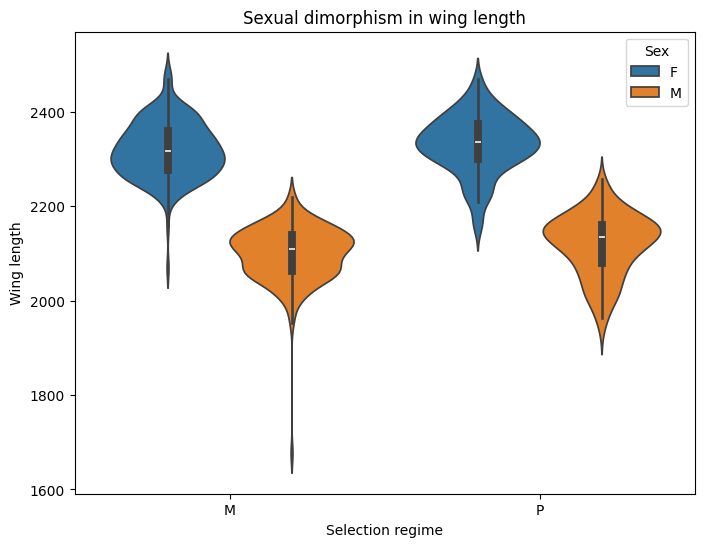

In [10]:
plt.figure(figsize=(8,6))
sns.violinplot(data=wing,x="Treatment",y="Length",hue="Sex")
plt.title("Sexual dimorphism in wing length")
plt.xlabel("Selection regime")
plt.ylabel("Wing length")

## 4. Desiccation survival analysis
Method:
Kaplan–Meier survival curves

Reference:
Kaplan & Meier 1958

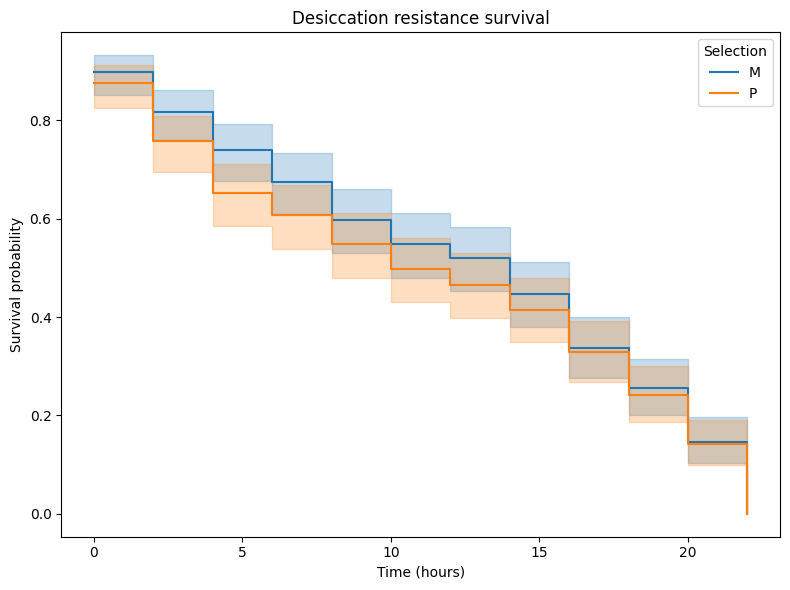

In [35]:
km = KaplanMeierFitter()

plt.figure(figsize=(8,6))

for g in des["Treatment"].unique():

    mask = des["Treatment"] == g

    km.fit(
        des.loc[mask,"Death_time"],
        event_observed=np.ones(mask.sum()),
        label=g
    )

    km.plot()

plt.title("Desiccation resistance survival")
plt.xlabel("Time (hours)")
plt.ylabel("Survival probability")

plt.legend(title="Selection")
plt.tight_layout()

### Starvation survival

In [36]:
starv["Death_time"] = pd.to_numeric(
    starv["Death_time"],
    errors="coerce"
)

starv["Death_time"].isna().sum()
starv = starv.dropna(subset=["Death_time"])

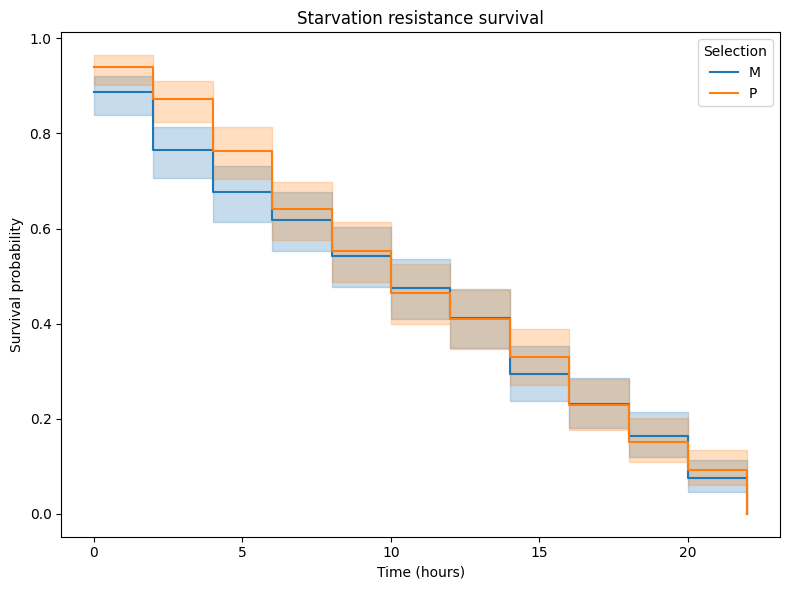

In [37]:
km = KaplanMeierFitter()

plt.figure(figsize=(8,6))

for g in starv["Treatment"].unique():

    mask = starv["Treatment"] == g

    km.fit(
        starv.loc[mask,"Death_time"],
        event_observed=np.ones(mask.sum()),
        label=g
    )

    km.plot()

plt.title("Starvation resistance survival")
plt.xlabel("Time (hours)")
plt.ylabel("Survival probability")

plt.legend(title="Selection")
plt.tight_layout()

## 5. Metabolic rate
Traits:
VO2
VCO2
RQ
activity

Text(0.5, 1.0, 'Metabolic rate evolution')

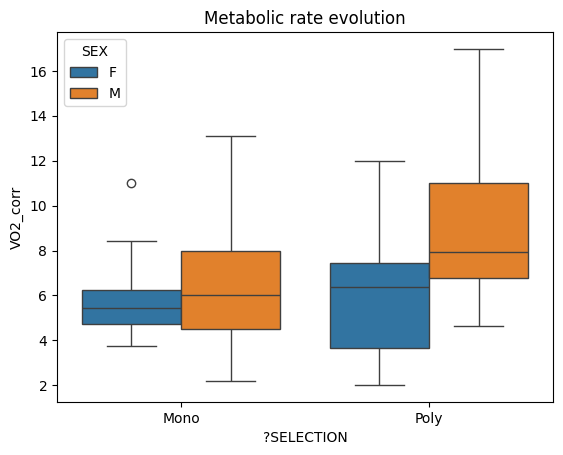

In [22]:
metabolic["VO2_corr"] = metabolic["VO2"]/metabolic["BODY_WEIGHT"]

sns.boxplot(data=metabolic,x="?SELECTION",y="VO2_corr",hue="SEX")  # metabolic.columns
plt.title("Metabolic rate evolution")


### Metabolite allocation

Traits:
lipid
glycogen
protein

Text(0.5, 1.0, 'Lipid allocation')

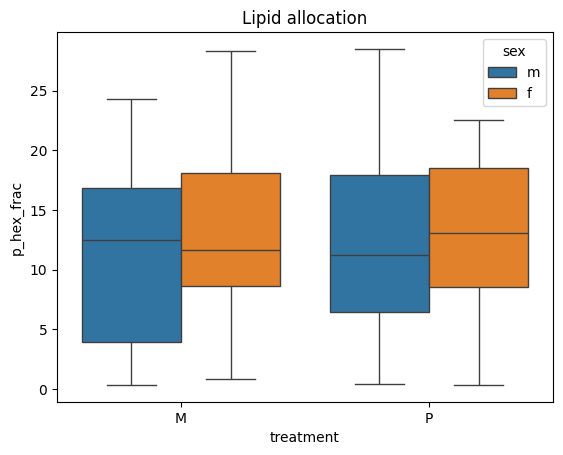

In [23]:
sns.boxplot(data=metabolite,x="treatment",y="p_hex_frac",hue="sex")
plt.title("Lipid allocation")

## 6. Sexual conflict analysis

Model:
trait ~ sex * treatment

Significant interaction = sexual conflict


In [24]:
model = ols("Length ~ Sex * Treatment", data=wing).fit()
sm.stats.anova_lm(model)

,df,sum_sq,mean_sq,F,PR(>F)
Sex,1.0,8.137819e+06,8.137819e+06,2141.357427,1.981126e-214
Treatment,1.0,4.408425e+04,4.408425e+04,11.600177,6.973974e-04
Sex:Treatment,1.0,2.819230e+03,2.819230e+03,0.741842,3.893684e-01
Residual,695.0,2.641214e+06,3.800309e+03,NaN,NaN


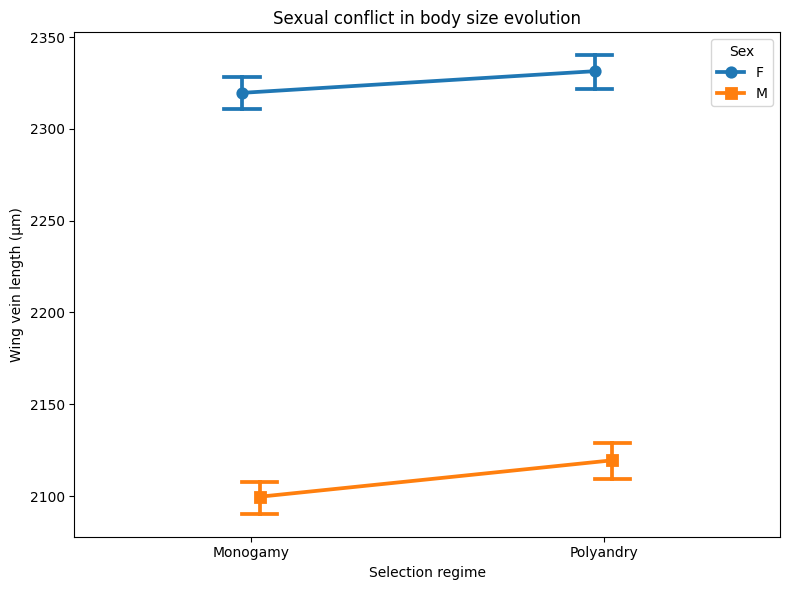

In [38]:
plt.figure(figsize=(8,6))

sns.pointplot(
    data=wing,
    x="Treatment",
    y="Length",
    hue="Sex",
    dodge=True,
    markers=["o","s"],
    capsize=.1
)

plt.title("Sexual conflict in body size evolution")
plt.xlabel("Selection regime")
plt.ylabel("Wing vein length (µm)")

plt.legend(title="Sex")

plt.tight_layout()

Crossing lines → sexual conflict

Parallel lines → no conflict

## 7. Multivariate evolution

PCA evolutionary trajectory

Reference:
Lande 1980 quantitative evolution

In [41]:
traits = metabolic[["VO2","VCO2","RQ","ACTIVITY"]]
pca = PCA()
pcs = pca.fit_transform(traits)

Text(0.5, 1.0, 'Evolutionary trajectory')

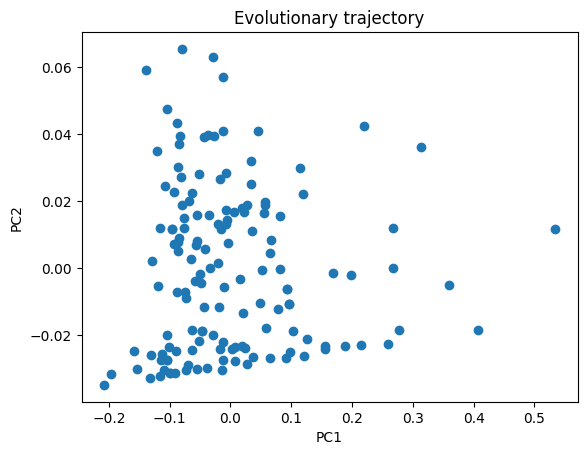

In [42]:
plt.scatter(pcs[:,0], pcs[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Evolutionary trajectory")

### 8. Final descriptive statistics

In [43]:
wing.groupby(["Treatment","Sex"])["Length"].mean()

Treatment  Sex
Monogamy   F      2319.590765
           M      2099.647583
Polyandry  F      2331.395921
           M      2119.490674
Name: Length, dtype: float64

# Analysis summary

Sexual selection affected:

- development time
- survival
- metabolism
- body size
- energy allocation

Sex-specific responses indicate sexual conflict.

# References
Hollis, Brian, et al. 2014. “Experimental Evolution under Monogamy and Polyandry.” Evolution.

Crudgington, H. S., et al. 2005. “Experimental Removal of Sexual Selection.” Nature.

Perry, Jessica, et al. 2016. “Sexual Selection and Metabolic Evolution.” Evolution Letters.

Kaplan, Edward L., and Paul Meier. 1958. “Nonparametric Estimation from Incomplete Observations.” Journal of the American Statistical Association.

Lande, Russell. 1980. “Sexual Dimorphism, Sexual Selection, and Adaptation.” Evolution.